### Theory

#### *Naive Bayes*

Probabilistic classifier that assumes features are independently informative for the class.

*Steps:*

1. Estimate per-class distributions of each feature.
2. Compute class likelihoods for a sample and pick the highest.
3. Use for fast baselines and well-separated classes.

#### *Support Vector Machine*

Maximizes margin between classes; the RBF kernel separates classes by mapping data to a higher-dimensional feature space.

*Steps:*

1. Scale features; choose C and gamma.
2. Train to find support vectors.
3. Predict using the learned decision function.

#### *Decision Tree*

Hierarchical rules learned by splitting features to create pure class regions.

*Steps:*

1. Recursively split on the best feature/threshold.
2. Stop by depth/min samples.
3. Predict using majority class in leaf nodes.

#### *Random Forest (bagging)*

Ensemble of many trees trained on bootstrapped samples with random feature selection; reduces overfitting by averaging.

*Steps:*

1. Train many trees on different subsets.
2. Aggregate predictions by majority vote.
3. Tune number of trees and max depth.

#### *AdaBoost (boosting)*

Sequentially focuses on hard examples by reweighting data; combines weak learners into a strong classifier.

*Steps:*

1. Initialize uniform weights on samples.
2. Iteratively train shallow trees; increase weights on misclassified samples.
3. Predict via weighted votes of all weak learners.

### Imports

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

### Utils

In [61]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * len(name))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    print("\nConfusion Matrix:")
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

### Data

In [62]:
RANDOM_STATE = 11

In [63]:
iris_df = load_iris(as_frame=True).frame

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [64]:
wine_df = load_wine(as_frame=True).frame

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [65]:
breast_cancer_df = load_breast_cancer(as_frame=True).frame

breast_cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<Figure size 1000x1000 with 0 Axes>

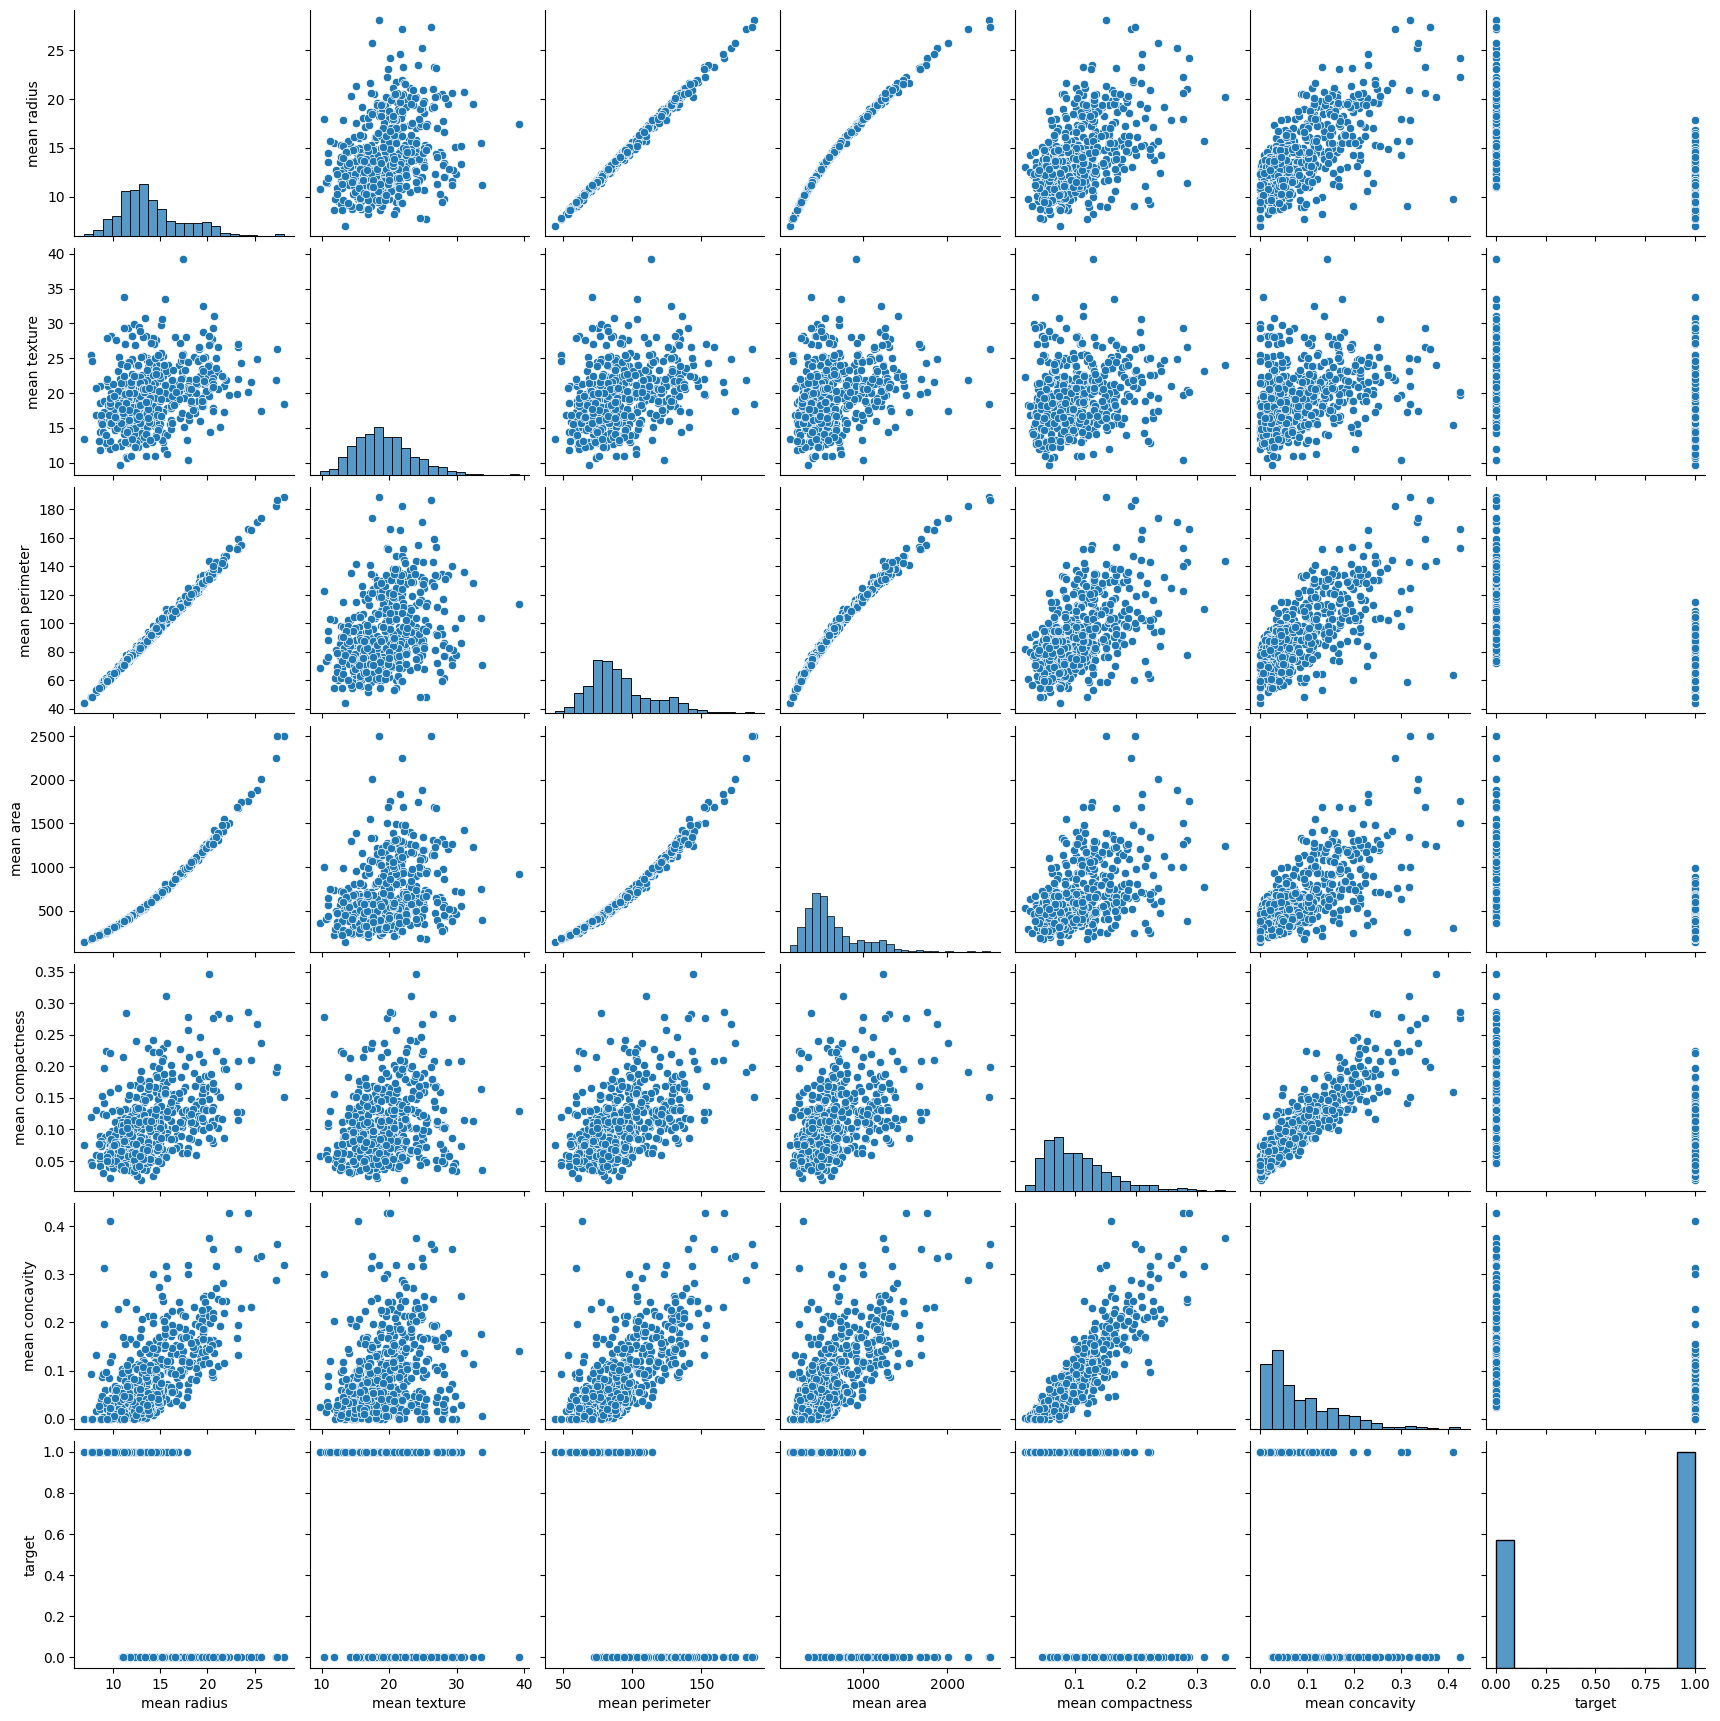

In [66]:
plt.figure(figsize=(10, 10))
sns.pairplot(data=breast_cancer_df, 
            x_vars=["mean radius", "mean texture", "mean perimeter", "mean area", "mean compactness", "mean concavity", "target"],
            y_vars=["mean radius", "mean texture", "mean perimeter", "mean area", "mean compactness", "mean concavity", "target"])
plt.show()

### Supervised Learning

In [67]:
X = breast_cancer_df.drop(columns="target")
y = breast_cancer_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Bayes


Naive Bayes
-----------
Accuracy: 0.9441
Balanced Accuracy: 0.9339

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        50
           1       0.95      0.97      0.96        93

    accuracy                           0.94       143
   macro avg       0.94      0.93      0.94       143
weighted avg       0.94      0.94      0.94       143


Confusion Matrix:


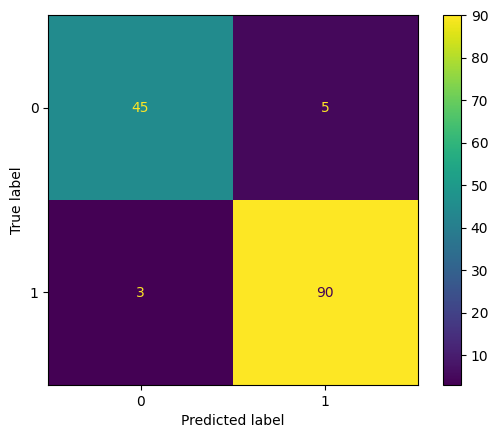

In [68]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

evaluate_model(
    "Naive Bayes",
    y_test,
    y_pred_nb
)

#### SVM


SVM
---
Accuracy: 0.9720
Balanced Accuracy: 0.9692

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        50
           1       0.98      0.98      0.98        93

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143


Confusion Matrix:


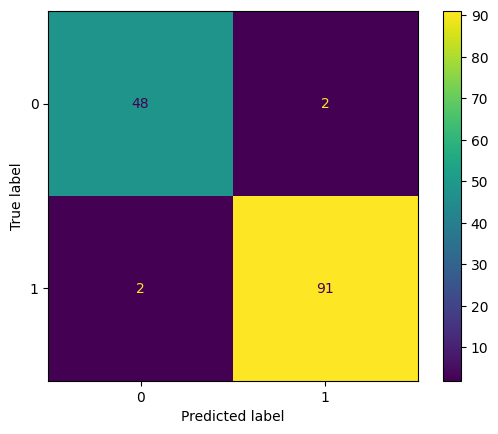

In [69]:
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

evaluate_model(
    "SVM",
    y_test,
    y_pred_svm
)

#### Decision Tree


Decision Tree
-------------
Accuracy: 0.9580
Balanced Accuracy: 0.9539

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.97      0.97      0.97        93

    accuracy                           0.96       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143


Confusion Matrix:


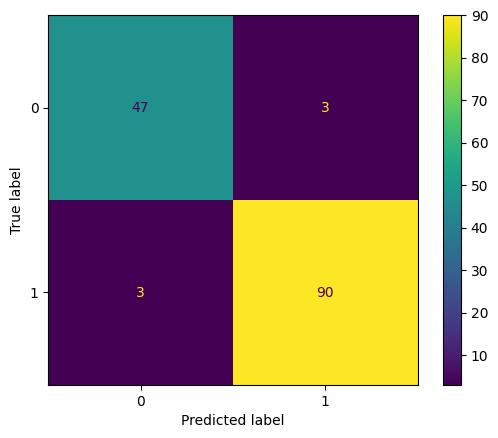

In [70]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

#### Random Forest


Random Forest
-------------
Accuracy: 0.9860
Balanced Accuracy: 0.9800

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.98      1.00      0.99        93

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143


Confusion Matrix:


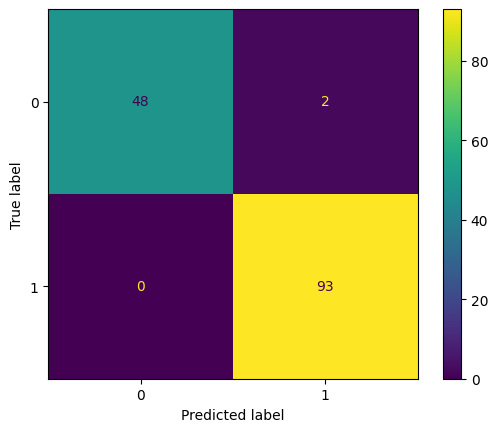

In [76]:
dt = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_dt
)

#### Boosting


Ada Boost
---------
Accuracy: 0.9860
Balanced Accuracy: 0.9846

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.99      0.99      0.99        93

    accuracy                           0.99       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143


Confusion Matrix:


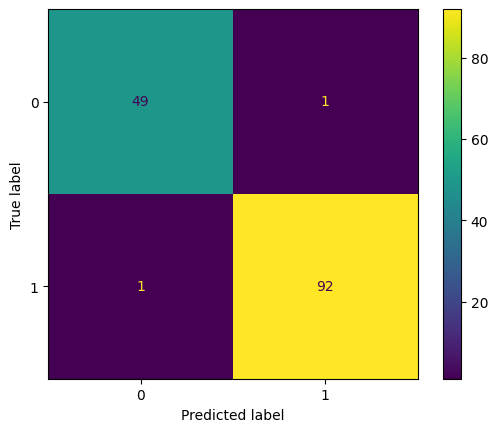

In [72]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=RANDOM_STATE)
ada.fit(X_train_scaled, y_train)

y_pred_ada = ada.predict(X_test_scaled)

evaluate_model(
    "Ada Boost",
    y_test,
    y_pred_ada
)